In [2]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load data
url = 'https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv'
df = pd.read_csv(url)

In [4]:
#checking dataset and get familiar with dataset
#check a small sample of dataset
# df.info()
# print(df.head(30))
print(df['race'].unique())
print(df['age'].unique())
print(df['gender'].unique())

['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
['Female' 'Male' 'Unknown/Invalid']


In [5]:
# cleaning
# found that in the race group, there are some cell with '?'
df['race'] = df['race'].replace('?', 'unknown')

# verify if ? is changed to unknown
print(df['race'].unique())

['Caucasian' 'AfricanAmerican' 'unknown' 'Other' 'Asian' 'Hispanic']


In [6]:
# calculate age distribution % of whole population and compare to each race group
# count occurance of age group by race
race_age_count=df.groupby(['race','age'])['encounter_id'].count()
# convert into percentage
race_age_percent=race_age_count/len(df)*100

#verify
print(race_age_percent.head(10))
#check size of the table, output 60 single row table
print(race_age_percent.shape)

race             age     
AfricanAmerican  [0-10)      0.015722
                 [10-20)     0.205373
                 [20-30)     0.530629
                 [30-40)     1.201777
                 [40-50)     2.738636
                 [50-60)     4.151681
                 [60-70)     4.158560
                 [70-80)     3.749779
                 [80-90)     1.785469
                 [90-100)    0.339013
Name: encounter_id, dtype: float64
(60,)


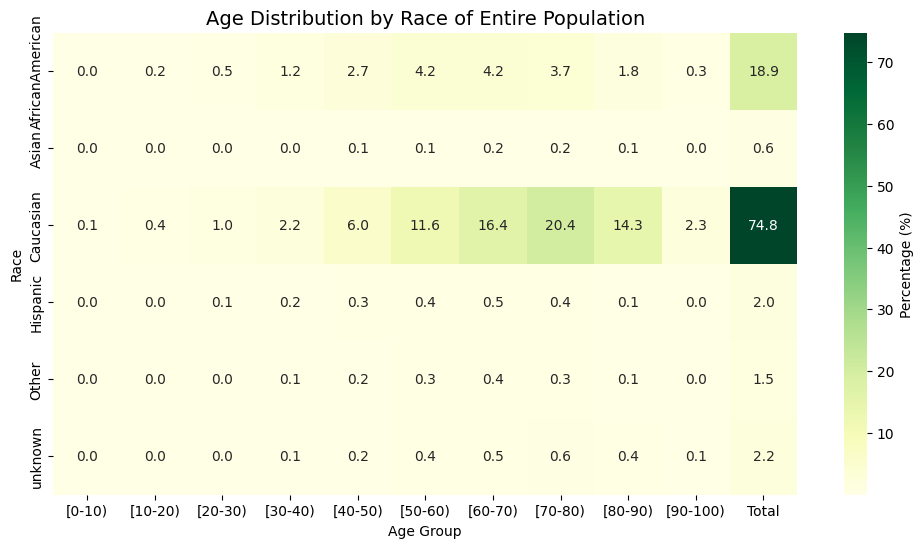

In [7]:
# visulization
# create heat map data
# groupby() creates series list but to make heatmap graph, it need to convert to dataframe/table format
heatmap_population_data=race_age_percent.unstack().fillna(0)
# add last column equals to sum of percentage of each race
heatmap_population_data['Total'] = heatmap_population_data.sum(axis=1)
# print(heatmap_data)

# plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_population_data,
            annot=True, #write data value in each cell
            fmt=".1f", #round value of each cell999999-
            cmap="YlGn",#color palette yellow to green
            cbar_kws={'label': 'Percentage (%)'}) #legend bar

plt.title('Age Distribution by Race of Entire Population', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Race')
plt.show()

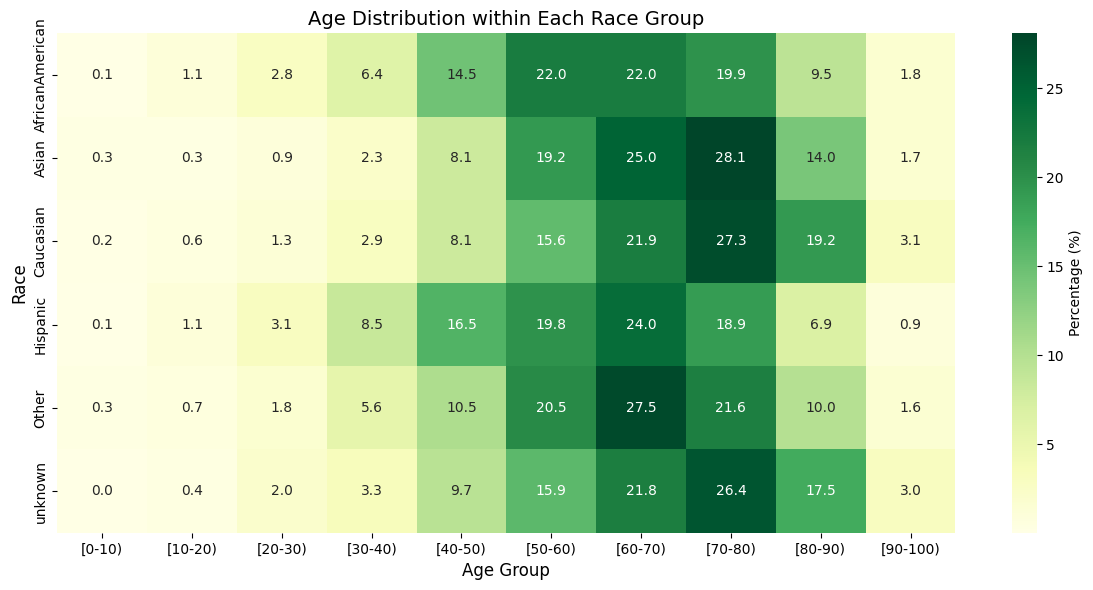

In [8]:
# calculate age distribution % within each race
# alternative method, use crosstab function

# crosstab(row, column,normalize='row/column/all'); normalize->making that to 100%
heatmap_race_data = pd.crosstab(df['race'], df['age'], normalize='index') * 100
# print(heatmap_race_data)

# plot the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_race_data,
            annot=True, #write data value in each cell
            fmt=".1f", #round value of each cell999999-
            cmap="YlGn",#color palette yellow to green
            cbar_kws={'label': 'Percentage (%)'}) #legend bar

plt.title('Age Distribution within Each Race Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Race', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
print('--------------------Summary---------------------')
print('The research question for this analysis is to determine the demographic profile of the diabetic patient population and which age and race groups represent the highest volume?')
print(f"In this diabetic population, {heatmap_population_data['Total'].idxmax()} has largest shares of patients, {heatmap_population_data['Total'].max():.1f}%")
print(f"and {heatmap_population_data['Total'].idxmin()} is the least represented, with only {heatmap_population_data['Total'].min():.1f}%.")
print()
n=3
# value_count() auto sorts most frequent items to lowest,index.astype(str) changes index to string,
# tolist() change to list format to a list of string
top_age_value=df['age'].value_counts().index.astype(str).tolist()
# print(top_age_value)
top_statement=", ".join(top_age_value[:n-1])+f", and {top_age_value[n-1]}"
print(f"Among all the age group, the top {n} age group with largest shares of patients are {top_statement}.")

--------------------Summary---------------------
The research question for this analysis is to determine the demographic profile of the diabetic patient population and which age and race groups represent the highest volume?
In this diabetic population, Caucasian has largest shares of patients, 74.8%
and Asian is the least represented, with only 0.6%.

Among all the age group, the top 3 age group with largest shares of patients are [70-80), [60-70), and [50-60).
